Name: Shubhajeet Das <br />
Roll No.: 24AI10013

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(os.listdir())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

['.config', 'sample_data']
Using device: cuda


In [2]:
!pip install torchinfo

# Task1: Data Loading and Spatial Pretext Setup

In [3]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import random

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [4]:
full_dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transform)

# Filter 'Forest' samples as the normal class
normal_class_idx = full_dataset.class_to_idx['Forest']
normal_data_indices = [i for i, (_, label) in enumerate(full_dataset) if label == normal_class_idx]

anomaly_data_indices = [i for i, (_, label) in enumerate(full_dataset) if label != normal_class_idx]

normal_dataset = torch.utils.data.Subset(full_dataset, normal_data_indices)

# Split normal data into 80% train and 20% validation
train_indices, val_indices = train_test_split(
    range(len(normal_dataset)),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_normal_dataset = torch.utils.data.Subset(normal_dataset, train_indices)
val_normal_dataset = torch.utils.data.Subset(normal_dataset, val_indices)

print(f"Total normal samples (Forest): {len(normal_dataset)}")
print(f"Training normal samples: {len(train_normal_dataset)}")
print(f"Validation normal samples: {len(val_normal_dataset)}")
print(f"Total anomaly samples: {len(anomaly_data_indices)}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 332MB/s]


Total normal samples (Forest): 3000
Training normal samples: 2400
Validation normal samples: 600
Total anomaly samples: 24000


In [5]:
import itertools

class JigsawDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.permutations = list(itertools.permutations(range(4)))

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        original_image, label = self.base_dataset[idx]
        if original_image.shape[-1] != 64 or original_image.shape[-2] != 64:
            raise ValueError("Image is not 64x64. Please ensure base_dataset provides 64x64 images.")

        patches = []
        # Top-left
        patches.append(original_image[:, :32, :32])
        # Top-right
        patches.append(original_image[:, :32, 32:])
        # Bottom-left
        patches.append(original_image[:, 32:, :32])
        # Bottom-right
        patches.append(original_image[:, 32:, 32:])

        # Choose a random permutation
        permutation_idx = random.randint(0, len(self.permutations) - 1)
        selected_permutation = self.permutations[permutation_idx]

        # Apply the permutation
        shuffled_patches = [patches[i] for i in selected_permutation]

        row1 = torch.cat((shuffled_patches[0], shuffled_patches[1]), dim=2)
        row2 = torch.cat((shuffled_patches[2], shuffled_patches[3]), dim=2)
        shuffled_patches_tensor = torch.cat((row1, row2), dim=1)

        return original_image, shuffled_patches_tensor, torch.tensor(permutation_idx, dtype=torch.long)

jigsaw_train_dataset = JigsawDataset(train_normal_dataset)
jigsaw_val_dataset = JigsawDataset(val_normal_dataset)

print(f"Jigsaw training dataset size: {len(jigsaw_train_dataset)}")
print(f"Jigsaw validation dataset size: {len(jigsaw_val_dataset)}")

Jigsaw training dataset size: 2400
Jigsaw validation dataset size: 600


In [6]:
original_img, shuffled_img, perm_idx = jigsaw_train_dataset[0]
print(f"Original image shape: {original_img.shape}")
print(f"Shuffled image shape: {shuffled_img.shape}")
print(f"Permutation index: {perm_idx}")

Original image shape: torch.Size([3, 64, 64])
Shuffled image shape: torch.Size([3, 64, 64])
Permutation index: 2


In [7]:
train_loader = DataLoader(jigsaw_train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader=DataLoader(jigsaw_val_dataset, batch_size=64, shuffle=True,  num_workers=2)

## Task 2: Visualization

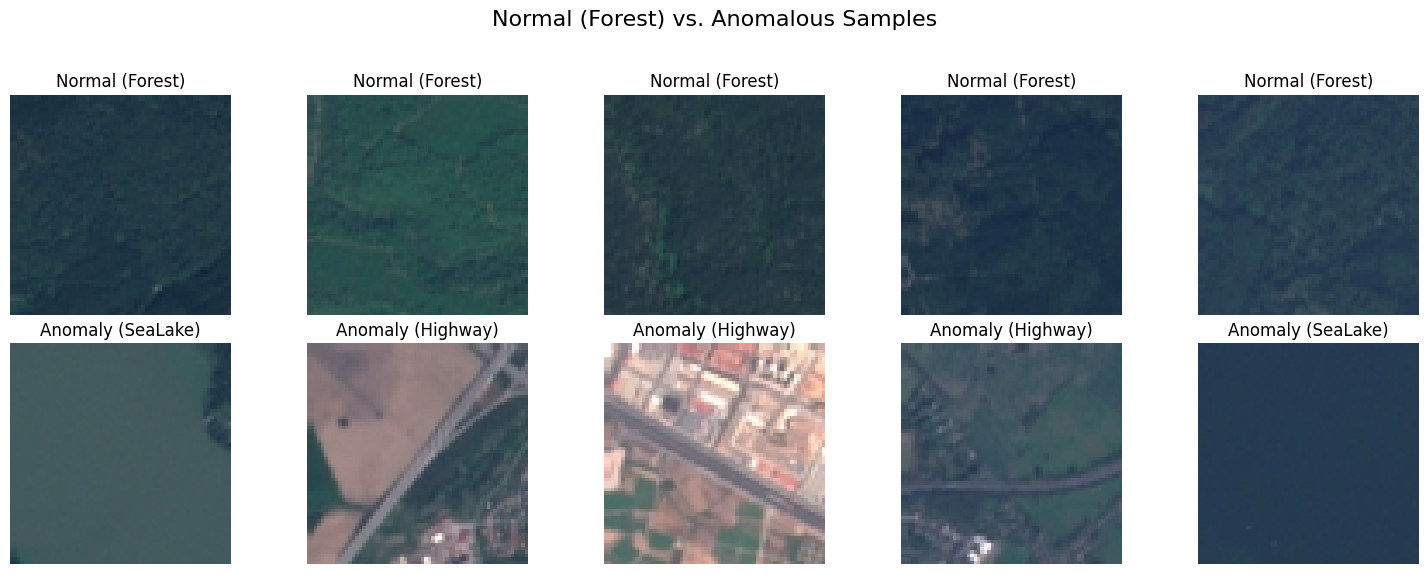

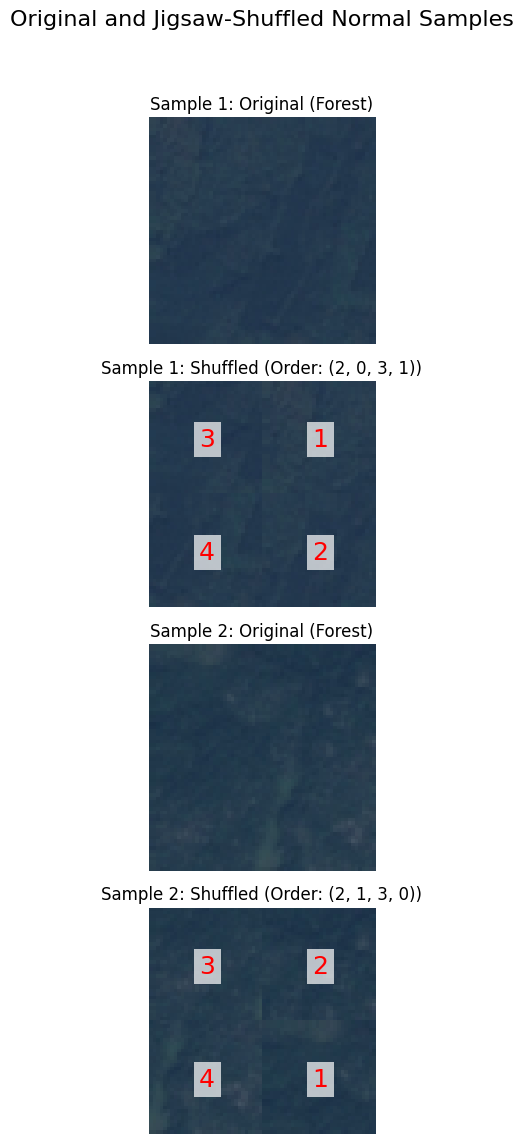

In [8]:
def denormalize(image_tensor):
    mean = torch.tensor([0.5, 0.5, 0.5], device=image_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5], device=image_tensor.device).view(3, 1, 1)
    denormalized_image = image_tensor * std + mean
    denormalized_image = torch.clamp(denormalized_image, 0, 1)
    return denormalized_image.permute(1, 2, 0).cpu().numpy()

num_samples_to_plot_a = 5

normal_sample_indices = random.sample(range(len(normal_dataset)), num_samples_to_plot_a)
normal_images = [normal_dataset[i][0] for i in normal_sample_indices]

anomaly_sample_indices_from_full = random.sample(anomaly_data_indices, num_samples_to_plot_a)
anomaly_samples_with_labels = [full_dataset[i] for i in anomaly_sample_indices_from_full]
anomaly_images = [s[0] for s in anomaly_samples_with_labels]
anomaly_labels = [full_dataset.classes[s[1]] for s in anomaly_samples_with_labels]

fig_a, axes_a = plt.subplots(2, num_samples_to_plot_a, figsize=(15, 6))
fig_a.suptitle('Normal (Forest) vs. Anomalous Samples', fontsize=16)

# Plot normal samples
for i in range(num_samples_to_plot_a):
    img = denormalize(normal_images[i])
    axes_a[0, i].imshow(img)
    axes_a[0, i].set_title(f'Normal (Forest)')
    axes_a[0, i].axis('off')

# Plot anomalous samples
for i in range(num_samples_to_plot_a):
    img = denormalize(anomaly_images[i])
    axes_a[1, i].imshow(img)
    axes_a[1, i].set_title(f'Anomaly ({anomaly_labels[i]})')
    axes_a[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

num_jigsaw_samples_to_plot_b = 2

fig_b, axes_b = plt.subplots(num_jigsaw_samples_to_plot_b * 2, 1, figsize=(6, 12))
fig_b.suptitle('Original and Jigsaw-Shuffled Normal Samples', fontsize=16)

permutations = jigsaw_train_dataset.permutations

for i in range(num_jigsaw_samples_to_plot_b):
    idx = random.randint(0, len(jigsaw_train_dataset) - 1)
    original_img, shuffled_img, perm_idx_tensor = jigsaw_train_dataset[idx]
    perm_idx = perm_idx_tensor.item()
    selected_permutation = permutations[perm_idx]

    # Plot original image
    ax_orig = axes_b[i * 2]
    ax_orig.imshow(denormalize(original_img))
    ax_orig.set_title(f'Sample {i+1}: Original (Forest)')
    ax_orig.axis('off')

    # Plot shuffled image
    ax_shuf = axes_b[i * 2 + 1]
    ax_shuf.imshow(denormalize(shuffled_img))
    ax_shuf.set_title(f'Sample {i+1}: Shuffled (Order: {selected_permutation})')
    ax_shuf.axis('off')

    text_coords_x = [16, 16, 48, 48] # Y-coordinate on the plot (row)
    text_coords_y = [16, 48, 16, 48] # X-coordinate on the plot (column)

    for patch_pos_in_shuffled_img in range(4):
        original_patch_index = selected_permutation[patch_pos_in_shuffled_img]
        label_text = str(original_patch_index + 1)

        ax_shuf.text(text_coords_y[patch_pos_in_shuffled_img],
                     text_coords_x[patch_pos_in_shuffled_img],
                     label_text,
                     color='red', fontsize=18, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Task 3: Architecture Design

In [9]:
import torch.nn as nn
from torchinfo import summary

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        # Input: 3x64x64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False), # Output: 32x32x32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 4, 2, 1, bias=False), # Output: 64x16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: 128x8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.flatten_size = 128 * 8 * 8 # 8192

        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

        self.enc_jigsaw = nn.Linear(self.flatten_size, 24)

    def forward(self, x):
        h = self.conv1(x)
        h = self.conv2(h)
        h = self.conv3(h)
        flattened_features = h.view(h.size(0), -1)

        mu = self.fc_mu(flattened_features)
        logvar = self.fc_logvar(flattened_features)
        jigsaw_logits = self.enc_jigsaw(flattened_features)

        return mu, logvar, jigsaw_logits


class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.linear = nn.Linear(latent_dim, 128 * 8 * 8)

        # Input: 128x8x8
        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False), # Output: 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False), # Output: 3x64x64
            nn.Tanh()
        )

    def forward(self, z):
        h = self.linear(z)
        h = h.view(h.size(0), 128, 8, 8)
        h = self.deconv1(h)
        h = self.deconv2(h)
        img = self.deconv3(h)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3x64x64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False), # Output: 32x32x32
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv2_features = nn.Sequential(
            nn.Conv2d(32, 64, 4, 2, 1, bias=False), # Output: 64x16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv3_final = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: 128x8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.flatten_size_layer2 = 64 * 16 * 16 # For disc_jigsaw head
        self.flatten_size_final = 128 * 8 * 8   # For final discriminator output

        self.disc_jigsaw = nn.Linear(self.flatten_size_layer2, 24)

        self.fc_final = nn.Sequential(
            nn.Linear(self.flatten_size_final, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h1 = self.conv1(x)
        features_from_layer2 = self.conv2_features(h1)

        jigsaw_logits = self.disc_jigsaw(features_from_layer2.view(features_from_layer2.size(0), -1))

        h3 = self.conv3_final(features_from_layer2)
        validity = self.fc_final(h3.view(h3.size(0), -1))

        return validity, features_from_layer2, jigsaw_logits


latent_dim = 128
encoder = Encoder(latent_dim).to(device)
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [10]:
print("--- Encoder Summary ---")
summary(encoder, input_size=(1, 3, 64, 64))

--- Encoder Summary ---


Layer (type:depth-idx)                   Output Shape              Param #
Encoder                                  [1, 128]                  --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           1,536
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─LeakyReLU: 2-3                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 16, 16]           32,768
│    └─BatchNorm2d: 2-5                  [1, 64, 16, 16]           128
│    └─LeakyReLU: 2-6                    [1, 64, 16, 16]           --
├─Sequential: 1-3                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-7                       [1, 128, 8, 8]            131,072
│    └─BatchNorm2d: 2-8                  [1, 128, 8, 8]            256
│    └─LeakyReLU: 2-9                    [1, 128, 8, 8]            --
├

In [11]:
print("\n--- Generator Summary ---")
summary(generator, input_size=(1, latent_dim))


--- Generator Summary ---


Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 64, 64]            --
├─Linear: 1-1                            [1, 8192]                 1,056,768
├─Sequential: 1-2                        [1, 64, 16, 16]           --
│    └─ConvTranspose2d: 2-1              [1, 64, 16, 16]           131,072
│    └─BatchNorm2d: 2-2                  [1, 64, 16, 16]           128
│    └─ReLU: 2-3                         [1, 64, 16, 16]           --
├─Sequential: 1-3                        [1, 32, 32, 32]           --
│    └─ConvTranspose2d: 2-4              [1, 32, 32, 32]           32,768
│    └─BatchNorm2d: 2-5                  [1, 32, 32, 32]           64
│    └─ReLU: 2-6                         [1, 32, 32, 32]           --
├─Sequential: 1-4                        [1, 3, 64, 64]            --
│    └─ConvTranspose2d: 2-7              [1, 3, 64, 64]            1,536
│    └─Tanh: 2-8                         [1, 3, 64, 64]          

In [12]:
print("\n--- Discriminator Summary ---")
summary(discriminator, input_size=(1, 3, 64, 64))


--- Discriminator Summary ---


Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           1,536
│    └─LeakyReLU: 2-2                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 64, 16, 16]           --
│    └─Conv2d: 2-3                       [1, 64, 16, 16]           32,768
│    └─BatchNorm2d: 2-4                  [1, 64, 16, 16]           128
│    └─LeakyReLU: 2-5                    [1, 64, 16, 16]           --
├─Linear: 1-3                            [1, 24]                   393,240
├─Sequential: 1-4                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-6                       [1, 128, 8, 8]            131,072
│    └─BatchNorm2d: 2-7                  [1, 128, 8, 8]            256
│    └─LeakyReLU: 2-8                    [1, 128, 8, 8]           

# Task 4

In [13]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

def generator_encoder_loss(x_real, x_recon, mu, logvar, d_real_features, d_recon_features, enc_jigsaw_logits, disc_jigsaw_logits, jigsaw_labels, lambda_1=0.1, lambda_2=0.5):
    # L_KL: KL Divergence loss
    l_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x_real.size(0)

    # L_adv: Binary Cross Entropy adversarial loss (Generator tries to fool the Discriminator)
    l_adv = F.binary_cross_entropy_with_logits(d_recon_features[0], torch.ones_like(d_recon_features[0]))

    # L_feat: L2 distance between Discriminator's layer-2 feature maps
    l_feat = torch.norm(d_real_features[1].detach() - d_recon_features[1], p=2) / x_real.size(0)

    # L_jigsaw: Cross-entropy loss for both enc_jigsaw and disc_jigsaw heads
    l_jigsaw_enc = F.cross_entropy(enc_jigsaw_logits, jigsaw_labels)
    l_jigsaw_disc = F.cross_entropy(disc_jigsaw_logits, jigsaw_labels)
    l_jigsaw = (l_jigsaw_enc + l_jigsaw_disc) # Summed from both heads

    return l_kl + l_adv + lambda_1 * l_feat + lambda_2 * l_jigsaw, l_kl.item(), l_adv.item(), l_feat.item(), l_jigsaw.item()

def discriminator_loss(d_real_output, d_fake_output, d_real_jigsaw_logits, d_fake_jigsaw_logits, jigsaw_labels, lambda_2=0.5):
    real_loss = F.binary_cross_entropy_with_logits(d_real_output, torch.ones_like(d_real_output))
    fake_loss = F.binary_cross_entropy_with_logits(d_fake_output, torch.zeros_like(d_fake_output))
    d_gan_loss = (real_loss + fake_loss) / 2

    d_jigsaw_loss_real = F.cross_entropy(d_real_jigsaw_logits, jigsaw_labels)
    d_jigsaw_loss_fake = F.cross_entropy(d_fake_jigsaw_logits, jigsaw_labels)
    d_jigsaw_total_loss = (d_jigsaw_loss_real + d_jigsaw_loss_fake)

    return d_gan_loss + lambda_2 * d_jigsaw_total_loss, d_gan_loss.item(), d_jigsaw_total_loss.item()

In [14]:
def train_vae_gan(encoder, generator, discriminator, train_loader, val_loader, epochs=25, lr=2e-4, lambda_1=0.1, lambda_2=0.5):
    optimizer_enc = torch.optim.Adam(encoder.parameters(), lr=lr)
    optimizer_gen = torch.optim.Adam(generator.parameters(), lr=lr)
    optimizer_disc = torch.optim.Adam(discriminator.parameters(), lr=lr)

    history = {
        'gen_enc_loss': [], 'disc_loss': [], 'kl_loss': [],
        'gen_adv_loss': [], 'feat_loss': [], 'jigsaw_loss_gen': [],
        'disc_gan_loss': [], 'jigsaw_loss_disc': [],
        'val_jigsaw_accuracy': [], 'val_kl_loss': [], 'val_total_gen_loss': []
    }

    saved_models = {}
    epochs_to_save = [1, 10, 25]

    for epoch in range(epochs):
        encoder.train()
        generator.train()
        discriminator.train()

        total_gen_enc_loss = 0.0
        total_disc_loss = 0.0
        total_kl_loss_train = 0.0
        total_gen_adv_loss = 0.0
        total_feat_loss = 0.0
        total_jigsaw_loss_gen = 0.0
        total_disc_gan_loss = 0.0
        total_jigsaw_loss_disc = 0.0

        num_batches = 0
        for original_imgs, shuffled_imgs, jigsaw_labels in train_loader:
            num_batches += 1
            original_imgs = original_imgs.to(device)
            shuffled_imgs = shuffled_imgs.to(device)
            jigsaw_labels = jigsaw_labels.to(device)

            #  Train Discriminator
            optimizer_disc.zero_grad()

            d_real_output, d_real_features, d_real_jigsaw_logits = discriminator(original_imgs)

            mu, logvar, enc_jigsaw_logits_for_gen = encoder(original_imgs)
            z = reparameterize(mu, logvar)
            x_recon = generator(z.detach())

            d_fake_output, d_fake_features, d_fake_jigsaw_logits = discriminator(x_recon.detach())

            d_loss, d_gan_l, d_jigsaw_l = discriminator_loss(d_real_output, d_fake_output, d_real_jigsaw_logits, d_fake_jigsaw_logits, jigsaw_labels, lambda_2)
            d_loss.backward()
            optimizer_disc.step()

            total_disc_loss += d_loss.item()
            total_disc_gan_loss += d_gan_l
            total_jigsaw_loss_disc += d_jigsaw_l

            #  Train Generator/Encoder
            optimizer_enc.zero_grad()
            optimizer_gen.zero_grad()

            mu, logvar, enc_jigsaw_logits = encoder(original_imgs)
            z = reparameterize(mu, logvar)
            x_recon = generator(z)

            d_recon_output, d_recon_features, d_recon_jigsaw_logits = discriminator(x_recon)

            d_real_output_for_gen, d_real_features_for_gen, _ = discriminator(original_imgs)

            gen_enc_l, kl_l, adv_l, feat_l, jigsaw_l_gen = generator_encoder_loss(original_imgs, x_recon, mu, logvar, (d_real_output_for_gen, d_real_features_for_gen), (d_recon_output, d_recon_features), enc_jigsaw_logits, d_recon_jigsaw_logits, jigsaw_labels, lambda_1, lambda_2)
            gen_enc_l.backward()
            optimizer_enc.step()
            optimizer_gen.step()

            total_gen_enc_loss += gen_enc_l.item()
            total_kl_loss_train += kl_l
            total_gen_adv_loss += adv_l
            total_feat_loss += feat_l
            total_jigsaw_loss_gen += jigsaw_l_gen

        history['gen_enc_loss'].append(total_gen_enc_loss / num_batches)
        history['disc_loss'].append(total_disc_loss / num_batches)
        history['kl_loss'].append(total_kl_loss_train / num_batches)
        history['gen_adv_loss'].append(total_gen_adv_loss / num_batches)
        history['feat_loss'].append(total_feat_loss / num_batches)
        history['jigsaw_loss_gen'].append(total_jigsaw_loss_gen / num_batches)
        history['disc_gan_loss'].append(total_disc_gan_loss / num_batches)
        history['jigsaw_loss_disc'].append(total_jigsaw_loss_disc / num_batches)

        #  Validation Step
        encoder.eval()
        generator.eval()
        discriminator.eval()

        val_kl_loss_epoch = 0.0
        val_total_gen_loss_epoch = 0.0
        correct_jigsaw_predictions = 0
        total_jigsaw_samples = 0

        with torch.no_grad():
            for original_imgs, shuffled_imgs, jigsaw_labels in val_loader:
                original_imgs = original_imgs.to(device)
                shuffled_imgs = shuffled_imgs.to(device)
                jigsaw_labels = jigsaw_labels.to(device)

                mu, logvar, enc_jigsaw_logits = encoder(original_imgs)
                z = reparameterize(mu, logvar)
                x_recon = generator(z)

                d_recon_output, d_recon_features, d_recon_jigsaw_logits = discriminator(x_recon)
                d_real_output, d_real_features, _ = discriminator(original_imgs)

                gen_enc_l_val, kl_l_val, _, _, _ = generator_encoder_loss(original_imgs, x_recon, mu, logvar, (d_real_output, d_real_features), (d_recon_output, d_recon_features), enc_jigsaw_logits, d_recon_jigsaw_logits, jigsaw_labels, lambda_1, lambda_2)
                val_total_gen_loss_epoch += gen_enc_l_val.item()
                val_kl_loss_epoch += kl_l_val

                _, predicted = torch.max(enc_jigsaw_logits.data, 1)
                total_jigsaw_samples += jigsaw_labels.size(0)
                correct_jigsaw_predictions += (predicted == jigsaw_labels).sum().item()

        val_jigsaw_accuracy = 100 * correct_jigsaw_predictions / total_jigsaw_samples
        val_kl_loss_epoch /= len(val_loader)
        val_total_gen_loss_epoch /= len(val_loader)

        history['val_jigsaw_accuracy'].append(val_jigsaw_accuracy)
        history['val_kl_loss'].append(val_kl_loss_epoch)
        history['val_total_gen_loss'].append(val_total_gen_loss_epoch)

        print(f"Epoch {epoch+1}/{epochs} | Gen/Enc Loss: {history['gen_enc_loss'][-1]:.4f} | Disc Loss: {history['disc_loss'][-1]:.4f} | KL Loss: {history['kl_loss'][-1]:.4f} | Val Jigsaw Acc: {val_jigsaw_accuracy:.2f}%")

        if (epoch + 1) in epochs_to_save:
            saved_models[f'epoch_{epoch+1}'] = {
                'encoder_state': encoder.state_dict(),
                'generator_state': generator.state_dict()
            }
        if epoch + 1 == 5:
            print(f"Validation Reconstruction Loss after 5 epochs: {val_total_gen_loss_epoch}")

    return history, saved_models

print("Training VAE-GAN...")
vae_gan_history, saved_models = train_vae_gan(encoder, generator, discriminator, train_loader, val_loader, epochs=25, lr=2e-4, lambda_1=0.1, lambda_2=0.5)

Training VAE-GAN...
Epoch 1/25 | Gen/Enc Loss: 9.2377 | Disc Loss: 3.8874 | KL Loss: 3.8820 | Val Jigsaw Acc: 4.33%
Epoch 2/25 | Gen/Enc Loss: 5.5071 | Disc Loss: 3.8108 | KL Loss: 0.4260 | Val Jigsaw Acc: 3.00%
Epoch 3/25 | Gen/Enc Loss: 5.0829 | Disc Loss: 3.8308 | KL Loss: 0.2268 | Val Jigsaw Acc: 3.67%
Epoch 4/25 | Gen/Enc Loss: 4.8348 | Disc Loss: 3.8017 | KL Loss: 0.1602 | Val Jigsaw Acc: 4.00%
Epoch 5/25 | Gen/Enc Loss: 4.5718 | Disc Loss: 3.8034 | KL Loss: 0.1270 | Val Jigsaw Acc: 3.17%
Validation Reconstruction Loss after 5 epochs: 5.360050439834595
Epoch 6/25 | Gen/Enc Loss: 4.3977 | Disc Loss: 3.7949 | KL Loss: 0.1026 | Val Jigsaw Acc: 3.50%
Epoch 7/25 | Gen/Enc Loss: 4.3435 | Disc Loss: 3.7925 | KL Loss: 0.0906 | Val Jigsaw Acc: 5.00%
Epoch 8/25 | Gen/Enc Loss: 4.2978 | Disc Loss: 3.7905 | KL Loss: 0.0718 | Val Jigsaw Acc: 5.17%
Epoch 9/25 | Gen/Enc Loss: 4.2567 | Disc Loss: 3.7617 | KL Loss: 0.0614 | Val Jigsaw Acc: 4.33%
Epoch 10/25 | Gen/Enc Loss: 4.2528 | Disc Loss: 3.7

# Task 5: Reconstruction Visualisation


--- Visualizing reconstructions for Epoch 1 ---


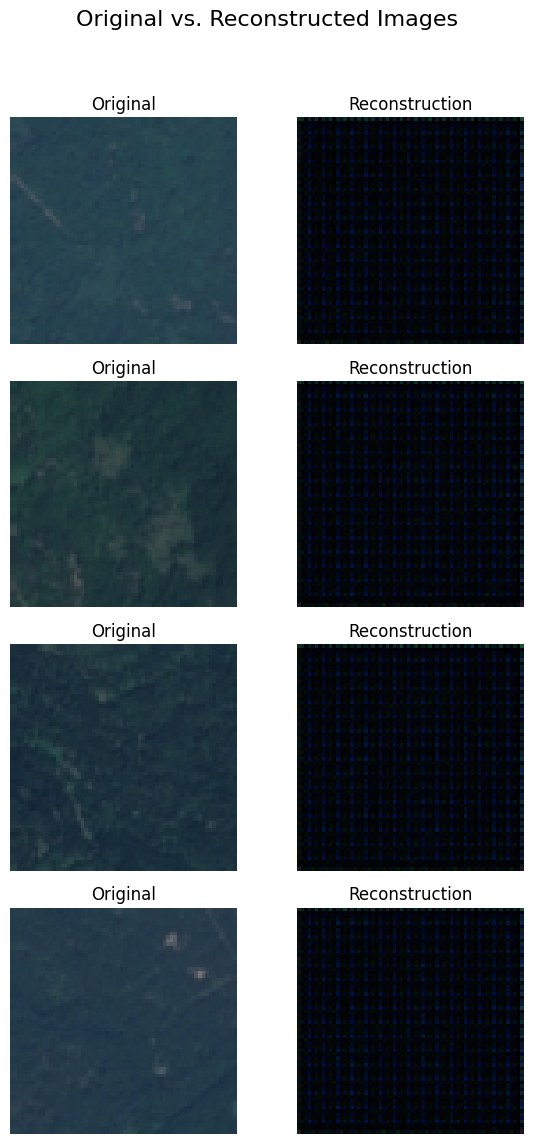


--- Visualizing reconstructions for Epoch 10 ---


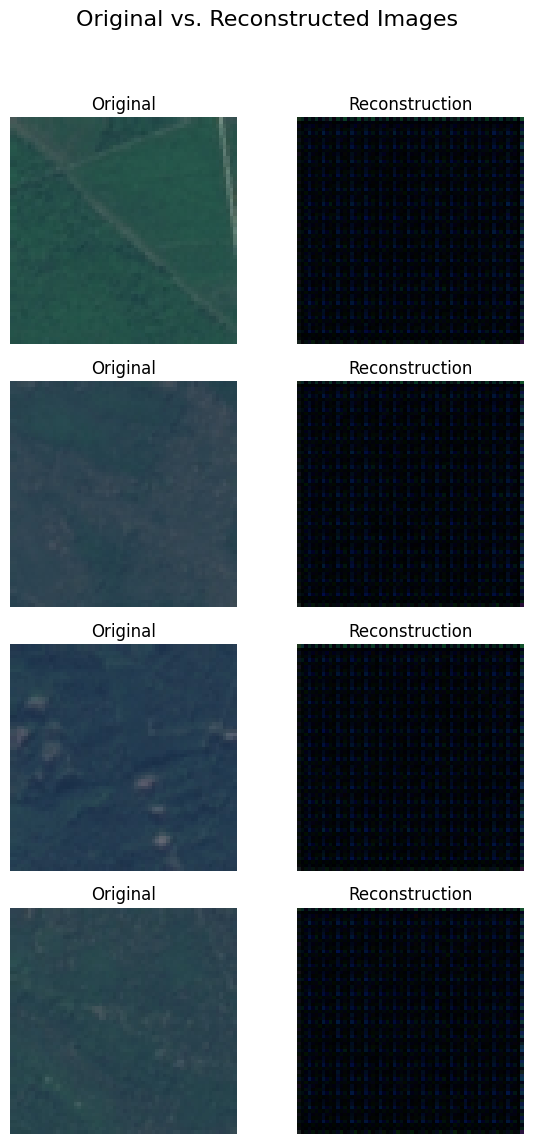


--- Visualizing reconstructions for Epoch 25 ---


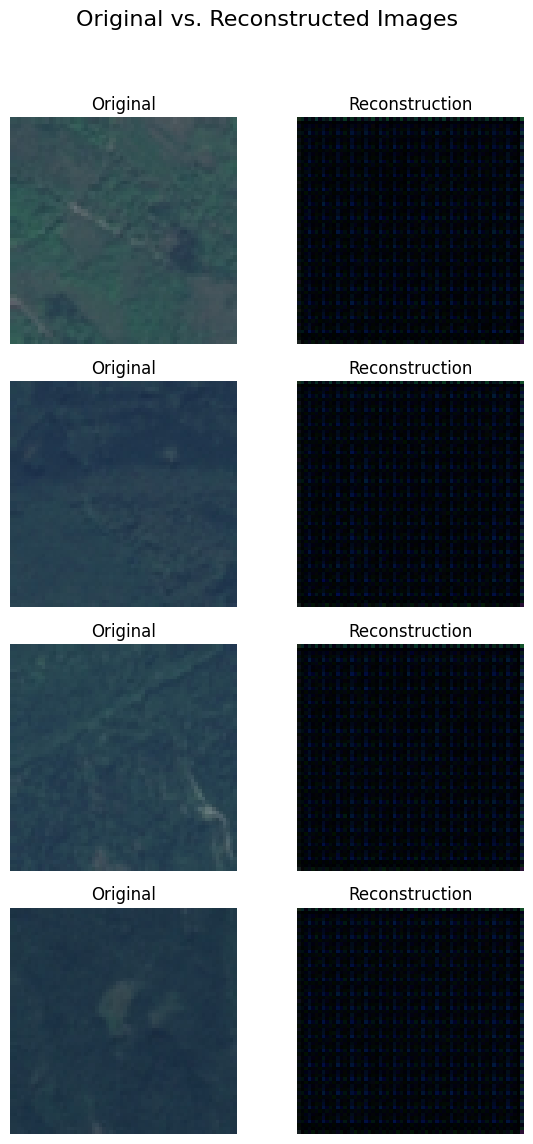

In [15]:
def visualize_reconstructions(encoder, generator, val_loader, num_samples=4):
    encoder.eval()
    generator.eval()

    original_imgs, _, _ = next(iter(val_loader))
    original_imgs = original_imgs[:num_samples].to(device)

    with torch.no_grad():
        mu, logvar, _ = encoder(original_imgs)
        z = reparameterize(mu, logvar)
        reconstructions = generator(z)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, num_samples * 3))
    fig.suptitle('Original vs. Reconstructed Images', fontsize=16)

    for i in range(num_samples):
        axes[i, 0].imshow(denormalize(original_imgs[i]))
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(denormalize(reconstructions[i]))
        axes[i, 1].set_title('Reconstruction')
        axes[i, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

epochs_to_visualize = [1, 10, 25]

for epoch in epochs_to_visualize:
    print(f"\n--- Visualizing reconstructions for Epoch {epoch} ---")
    current_encoder = Encoder(latent_dim).to(device)
    current_generator = Generator(latent_dim).to(device)

    current_encoder.load_state_dict(saved_models[f'epoch_{epoch}']['encoder_state'])
    current_generator.load_state_dict(saved_models[f'epoch_{epoch}']['generator_state'])

    visualize_reconstructions(current_encoder, current_generator, val_loader)


## Task 6: Ablation Study

### Variant A: No SSL (lambda_2 = 0)

In [16]:
encoder_A = Encoder(latent_dim).to(device)
generator_A = Generator(latent_dim).to(device)
discriminator_A = Discriminator().to(device)

print("Training Variant A: No SSL (lambda_2=0)...")
vae_gan_history_A, saved_models_A = train_vae_gan(encoder_A, generator_A, discriminator_A, train_loader, val_loader, epochs=5, lr=2e-4, lambda_1=0.1, lambda_2=0)

val_recon_loss_A = vae_gan_history_A['val_total_gen_loss'][-1]
val_jigsaw_acc_A = vae_gan_history_A['val_jigsaw_accuracy'][-1]
print(f"\nVariant A (No SSL) - Final Validation Reconstruction Loss: {val_recon_loss_A:.4f}")
print(f"Variant A (No SSL) - Final Validation Jigsaw Accuracy: {val_jigsaw_acc_A:.2f}%")

Training Variant A: No SSL (lambda_2=0)...
Epoch 1/5 | Gen/Enc Loss: 5.5737 | Disc Loss: 0.5192 | KL Loss: 3.5249 | Val Jigsaw Acc: 4.67%
Epoch 2/5 | Gen/Enc Loss: 2.3036 | Disc Loss: 0.5036 | KL Loss: 0.4215 | Val Jigsaw Acc: 4.83%
Epoch 3/5 | Gen/Enc Loss: 1.9467 | Disc Loss: 0.5035 | KL Loss: 0.2327 | Val Jigsaw Acc: 4.83%
Epoch 4/5 | Gen/Enc Loss: 1.7305 | Disc Loss: 0.5034 | KL Loss: 0.1658 | Val Jigsaw Acc: 4.33%
Epoch 5/5 | Gen/Enc Loss: 1.5791 | Disc Loss: 0.5040 | KL Loss: 0.1332 | Val Jigsaw Acc: 4.17%
Validation Reconstruction Loss after 5 epochs: 2.5594486951828004

Variant A (No SSL) - Final Validation Reconstruction Loss: 2.5594
Variant A (No SSL) - Final Validation Jigsaw Accuracy: 4.17%


### Variant B: SSL Only


In [17]:
class JigsawOnlyEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.flatten_size = 128 * 8 * 8
        self.enc_jigsaw = nn.Linear(self.flatten_size, 24)

    def forward(self, x):
        h = self.conv1(x)
        h = self.conv2(h)
        h = self.conv3(h)
        flattened_features = h.view(h.size(0), -1)
        jigsaw_logits = self.enc_jigsaw(flattened_features)
        return jigsaw_logits

def train_jigsaw_only(model, train_loader, val_loader, epochs=5, lr=2e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'jigsaw_loss': [], 'val_jigsaw_accuracy': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0
        for _, shuffled_imgs, jigsaw_labels in train_loader:
            num_batches += 1
            shuffled_imgs = shuffled_imgs.to(device)
            jigsaw_labels = jigsaw_labels.to(device)

            optimizer.zero_grad()
            logits = model(shuffled_imgs)
            loss = criterion(logits, jigsaw_labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        history['jigsaw_loss'].append(total_loss / num_batches)

        # Validation
        model.eval()
        correct_jigsaw_predictions = 0
        total_jigsaw_samples = 0
        with torch.no_grad():
            for _, shuffled_imgs, jigsaw_labels in val_loader:
                shuffled_imgs = shuffled_imgs.to(device)
                jigsaw_labels = jigsaw_labels.to(device)
                logits = model(shuffled_imgs)
                _, predicted = torch.max(logits.data, 1)
                total_jigsaw_samples += jigsaw_labels.size(0)
                correct_jigsaw_predictions += (predicted == jigsaw_labels).sum().item()

        val_jigsaw_accuracy = 100 * correct_jigsaw_predictions / total_jigsaw_samples
        history['val_jigsaw_accuracy'].append(val_jigsaw_accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Jigsaw Loss: {history['jigsaw_loss'][-1]:.4f} | Val Jigsaw Acc: {val_jigsaw_accuracy:.2f}%")

    return history

# Instantiate and train Variant B
jigsaw_only_encoder = JigsawOnlyEncoder(latent_dim).to(device)
print("\nTraining Variant B: SSL Only...")
vae_gan_history_B = train_jigsaw_only(jigsaw_only_encoder, train_loader, val_loader, epochs=5, lr=2e-4)

val_jigsaw_acc_B = vae_gan_history_B['val_jigsaw_accuracy'][-1]
print(f"Variant B (SSL Only) - Final Validation Jigsaw Accuracy: {val_jigsaw_acc_B:.2f}%")


Training Variant B: SSL Only...
Epoch 1/5 | Jigsaw Loss: 3.3402 | Val Jigsaw Acc: 4.50%
Epoch 2/5 | Jigsaw Loss: 3.3014 | Val Jigsaw Acc: 6.17%
Epoch 3/5 | Jigsaw Loss: 3.2565 | Val Jigsaw Acc: 4.67%
Epoch 4/5 | Jigsaw Loss: 3.2451 | Val Jigsaw Acc: 4.17%
Epoch 5/5 | Jigsaw Loss: 3.2450 | Val Jigsaw Acc: 5.00%
Variant B (SSL Only) - Final Validation Jigsaw Accuracy: 5.00%


### Ablation Study Summary
(after 5 epochs)
| Variant                       | Val. Reconstruction Loss | Jigsaw Val. Accuracy |
| :------------ | :---------- | :--------- |
| Full VAE-GAN + SSL (Task 4) | 5.36  | 3.17% |
| Variant A: No SSL | 2.56 | 4.17% |
| Variant B: SSL only | NA | 5.00% |


### Commentary
Variant A performs best in Val. reconstruction loss and Variant B performs best in jigsaw val accuracy.

## Task 7: Anomaly Scoring with SSL Augmentation

In [18]:
# Create a balanced test set: 200 normal + 200 anomalous samples

all_normal_indices_set = set(range(len(normal_dataset)))
train_val_indices_set = set(train_indices).union(set(val_indices))
independent_normal_indices = list(all_normal_indices_set - train_val_indices_set)

num_test_samples = 200

# Randomly select normal samples for the test set (can overlap with validation due to previous splits)
normal_test_indices = random.sample(range(len(normal_dataset)), num_test_samples)
normal_test_dataset = torch.utils.data.Subset(normal_dataset, normal_test_indices)

# Randomly select anomalous samples for the test set
anomaly_test_indices = random.sample(anomaly_data_indices, num_test_samples)
anomaly_test_dataset = torch.utils.data.Subset(full_dataset, anomaly_test_indices)

class AnomalyTestDataset(Dataset):
    def __init__(self, normal_subset, anomaly_subset):
        self.normal_subset = normal_subset
        self.anomaly_subset = anomaly_subset
        self.data = []
        self.labels = [] # 0 for normal, 1 for anomaly

        for i in range(len(normal_subset)):
            img, _ = normal_subset[i]
            self.data.append(img)
            self.labels.append(0) # Normal

        for i in range(len(anomaly_subset)):
            img, _ = anomaly_subset[i]
            self.data.append(img)
            self.labels.append(1) # Anomaly

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

test_set_combined = AnomalyTestDataset(normal_test_dataset, anomaly_test_dataset)
test_loader = DataLoader(test_set_combined, batch_size=64, shuffle=False) # Shuffle=False for consistent evaluation

print(f"Test set (normal): {len(normal_test_dataset)} samples")
print(f"Test set (anomaly): {len(anomaly_test_dataset)} samples")
print(f"Combined Test set: {len(test_set_combined)} samples")

Test set (normal): 200 samples
Test set (anomaly): 200 samples
Combined Test set: 400 samples


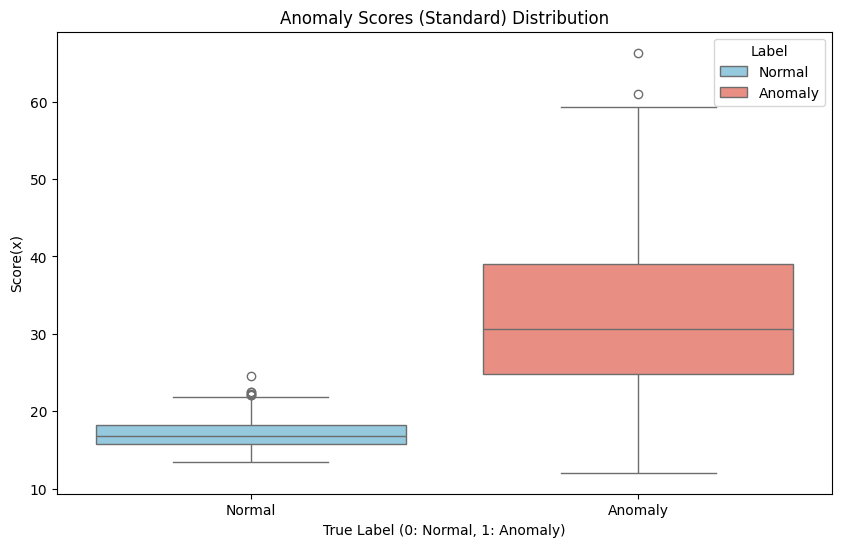

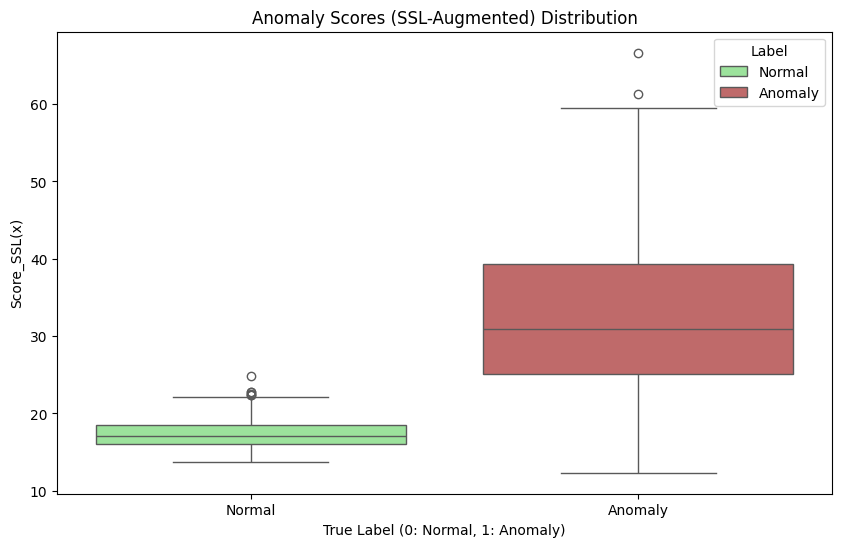

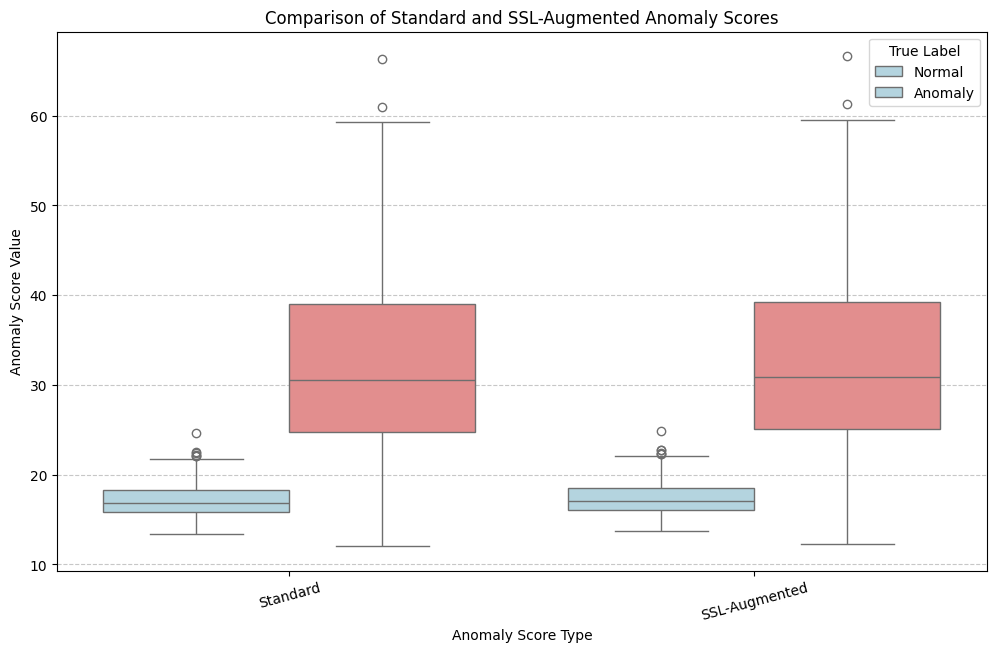


Which score gives better class separation? (Based on the box plots)
Answer: SSL augmented


In [23]:
import pandas as pd

def get_p_correct(encoder_model, image_tensor, jigsaw_dataset):
    class SingleImageDataset(Dataset):
        def __init__(self, img):
            self.img = img
        def __len__(self):
            return 1
        def __getitem__(self, idx):
            return self.img, 0

    temp_jigsaw_dataset = JigsawDataset(SingleImageDataset(image_tensor.cpu()))
    _, shuffled_img, correct_perm_idx = temp_jigsaw_dataset[0]
    shuffled_img = shuffled_img.unsqueeze(0).to(device)

    encoder_model.eval()
    with torch.no_grad():
        _, _, enc_jigsaw_logits = encoder_model(shuffled_img)
        softmax_probs = F.softmax(enc_jigsaw_logits, dim=1)
        p_correct = softmax_probs[0, correct_perm_idx].item()
    return p_correct


def calculate_anomaly_scores(encoder_model, generator_model, discriminator_model, data_loader, lambda_val=0.5, gamma_val=0.3):
    encoder_model.eval()
    generator_model.eval()
    discriminator_model.eval()

    scores = []
    scores_ssl = []
    true_labels = [] # 0 for normal, 1 for anomaly

    with torch.no_grad():
        for original_imgs, labels in data_loader:
            original_imgs = original_imgs.to(device)

            # Encode and Reconstruct
            mu, logvar, _ = encoder_model(original_imgs)
            z = reparameterize(mu, logvar)
            reconstructions = generator_model(z)

            # Get Discriminator Features
            _, d_real_features, _ = discriminator_model(original_imgs)
            _, d_recon_features, _ = discriminator_model(reconstructions)

            recon_error = torch.mean(torch.abs(original_imgs - reconstructions), dim=[1, 2, 3])

            feat_error = torch.mean(torch.square(d_real_features - d_recon_features), dim=[1, 2, 3])

            feat_error_per_sample = torch.sum(torch.square(d_real_features - d_recon_features).view(original_imgs.size(0), -1), dim=1).sqrt()

            score_1 = lambda_val * recon_error + (1 - lambda_val) * feat_error_per_sample
            scores.extend(score_1.cpu().numpy())

            p_correct_batch = []
            for i in range(original_imgs.size(0)):
                p_correct_batch.append(get_p_correct(encoder_model, original_imgs[i], jigsaw_train_dataset)) # Pass jigsaw_train_dataset for permutations
            p_correct_batch = torch.tensor(p_correct_batch, device=device)

            score_2 = score_1 + gamma_val * (1 - p_correct_batch)
            scores_ssl.extend(score_2.cpu().numpy())

            true_labels.extend(labels.cpu().numpy())

    return np.array(scores), np.array(scores_ssl), np.array(true_labels)

final_encoder = Encoder(latent_dim).to(device)
final_generator = Generator(latent_dim).to(device)
final_discriminator = Discriminator().to(device)

final_encoder.load_state_dict(saved_models['epoch_25']['encoder_state'])
final_generator.load_state_dict(saved_models['epoch_25']['generator_state'])

scores_full, scores_ssl_full, labels_full = calculate_anomaly_scores(
    final_encoder, final_generator, discriminator, test_loader, lambda_val=0.5, gamma_val=0.3
)

plt.figure(figsize=(10, 6))
sns.boxplot(x=labels_full, y=scores_full, hue=labels_full, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Anomaly Scores (Standard) Distribution')
plt.xlabel('True Label (0: Normal, 1: Anomaly)')
plt.ylabel('Score(x)')
plt.xticks([0, 1], ['Normal', 'Anomaly'])
plt.legend(title='Label', loc='upper right', labels=['Normal', 'Anomaly'])
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=labels_full, y=scores_ssl_full, hue=labels_full, palette={0: 'lightgreen', 1: 'indianred'})
plt.title('Anomaly Scores (SSL-Augmented) Distribution')
plt.xlabel('True Label (0: Normal, 1: Anomaly)')
plt.ylabel('Score_SSL(x)')
plt.xticks([0, 1], ['Normal', 'Anomaly'])
plt.legend(title='Label', loc='upper right', labels=['Normal', 'Anomaly'])
plt.show()

data_to_plot = {
    'Score': np.concatenate([scores_full, scores_ssl_full]),
    'Score Type': ['Standard'] * len(scores_full) + ['SSL-Augmented'] * len(scores_ssl_full),
    'True Label': np.concatenate([labels_full, labels_full])
}
df_scores = pd.DataFrame(data_to_plot)

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_scores, x='Score Type', y='Score', hue='True Label', palette={0: 'lightblue', 1: 'lightcoral'})
plt.title('Comparison of Standard and SSL-Augmented Anomaly Scores')
plt.xlabel('Anomaly Score Type')
plt.ylabel('Anomaly Score Value')
plt.xticks(rotation=15)
plt.legend(title='True Label', loc='upper right', labels=['Normal', 'Anomaly'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nWhich score gives better class separation? (Based on the box plots)")
print("Answer: SSL augmented")

# Task 8: Evaluation and Written Reasoning

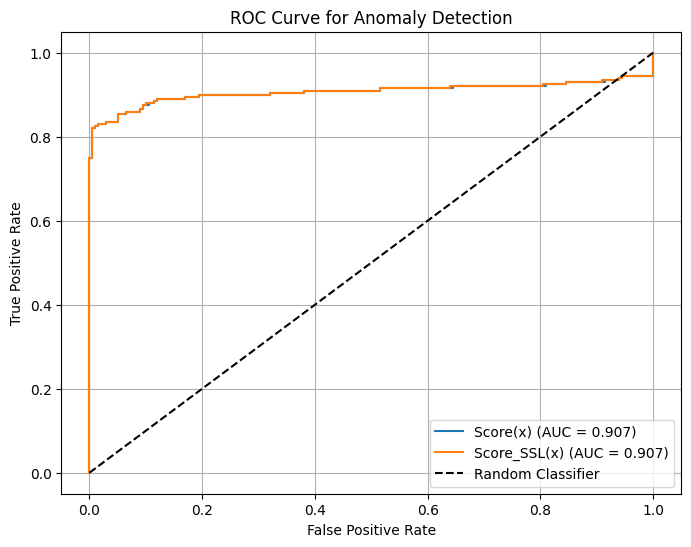

AUC for Score(x): 0.907
AUC for Score_SSL(x): 0.907


In [20]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

fpr_full, tpr_full, _ = roc_curve(labels_full, scores_full)
auc_full = auc(fpr_full, tpr_full)
plt.plot(fpr_full, tpr_full, label=f'Score(x) (AUC = {auc_full:.3f})')

fpr_ssl_full, tpr_ssl_full, _ = roc_curve(labels_full, scores_ssl_full)
auc_ssl_full = auc(fpr_ssl_full, tpr_ssl_full)
plt.plot(fpr_ssl_full, tpr_ssl_full, label=f'Score_SSL(x) (AUC = {auc_ssl_full:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC for Score(x): {auc_full:.3f}")
print(f"AUC for Score_SSL(x): {auc_ssl_full:.3f}")

In [21]:

def get_metrics_at_recall(true_labels, scores, target_recall=0.9):
    precisions, recalls, thresholds = precision_recall_curve(true_labels, scores)

    best_threshold_idx = -1
    for i in range(len(recalls)):
        if recalls[i] >= target_recall:
            best_threshold_idx = i
            break

    if best_threshold_idx == -1:
        print(f"Could not find a threshold that achieves {target_recall*100}% recall. Max recall achieved: {recalls[0]:.2f}")
        idx = np.abs(recalls - target_recall).argmin()
        threshold_for_recall = thresholds[idx]
        predicted_labels = (scores >= threshold_for_recall).astype(int)
        current_recall = recall_score(true_labels, predicted_labels)
        print(f"Using threshold {threshold_for_recall:.3f} to achieve recall {current_recall:.3f} (closest to {target_recall:.1f})")
    else:
        threshold_for_recall = thresholds[best_threshold_idx]
        predicted_labels = (scores >= threshold_for_recall).astype(int)

    current_precision = precision_score(true_labels, predicted_labels)
    current_f1 = f1_score(true_labels, predicted_labels)
    current_recall = recall_score(true_labels, predicted_labels)

    return current_precision, current_f1, threshold_for_recall, current_recall

target_recall = 0.90

prec_full, f1_full, thresh_full, recall_full = get_metrics_at_recall(labels_full, scores_full, target_recall)
print(f"\nScore(x) at {target_recall*100:.0f}% Recall (achieved {recall_full*100:.1f}%):\n  Threshold: {thresh_full:.4f}\n  Precision: {prec_full:.3f}\n  F1-Score: {f1_full:.3f}")

prec_ssl_full, f1_ssl_full, thresh_ssl_full, recall_ssl_full = get_metrics_at_recall(labels_full, scores_ssl_full, target_recall)
print(f"\nScore_SSL(x) at {target_recall*100:.0f}% Recall (achieved {recall_ssl_full*100:.1f}%):\n  Threshold: {thresh_ssl_full:.4f}\n  Precision: {prec_ssl_full:.3f}\n  F1-Score: {f1_ssl_full:.3f}")


Score(x) at 90% Recall (achieved 100.0%):
  Threshold: 12.0921
  Precision: 0.500
  F1-Score: 0.667

Score_SSL(x) at 90% Recall (achieved 100.0%):
  Threshold: 12.3841
  Precision: 0.500
  F1-Score: 0.667


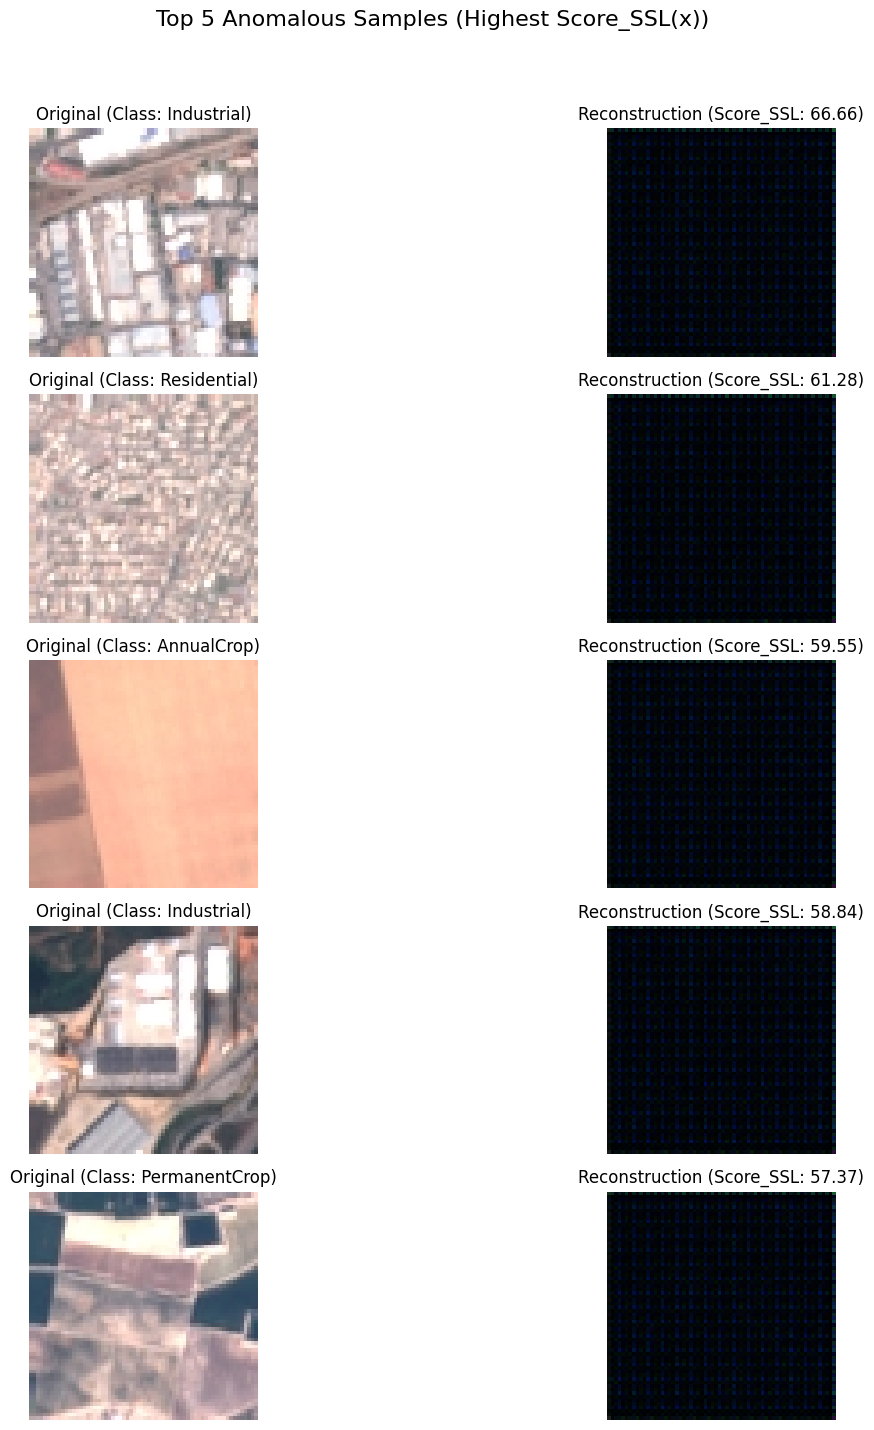

In [22]:
num_top_anomalies = 5

anomaly_indices_in_test_set = np.where(labels_full == 1)[0]
anomaly_scores_ssl = scores_ssl_full[anomaly_indices_in_test_set]

sorted_anomaly_indices_by_score = anomaly_indices_in_test_set[np.argsort(anomaly_scores_ssl)][::-1]

top_anomaly_global_indices = sorted_anomaly_indices_by_score[:num_top_anomalies]

plt.figure(figsize=(15, num_top_anomalies * 3))
plt.suptitle(f'Top {num_top_anomalies} Anomalous Samples (Highest Score_SSL(x))', fontsize=16)

for i, global_idx in enumerate(top_anomaly_global_indices):
    original_img_tensor, true_label_idx = test_set_combined[global_idx]

    if global_idx >= len(normal_test_dataset):
        anomaly_subset_idx = global_idx - len(normal_test_dataset)
        _, eurosat_class_idx = anomaly_test_dataset[anomaly_subset_idx]
        true_class_name = full_dataset.classes[eurosat_class_idx]
    else:
        true_class_name = 'Forest'

    original_img_tensor_batch = original_img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        mu, logvar, _ = final_encoder(original_img_tensor_batch)
        z = reparameterize(mu, logvar)
        reconstruction_tensor_batch = final_generator(z)

    original_img_plot = denormalize(original_img_tensor)
    reconstruction_plot = denormalize(reconstruction_tensor_batch.squeeze(0))

    score_value = scores_ssl_full[global_idx]

    ax = plt.subplot(num_top_anomalies, 2, i * 2 + 1)
    ax.imshow(original_img_plot)
    ax.set_title(f'Original (Class: {true_class_name})')
    ax.axis('off')

    ax = plt.subplot(num_top_anomalies, 2, i * 2 + 2)
    ax.imshow(reconstruction_plot)
    ax.set_title(f'Reconstruction (Score_SSL: {score_value:.2f})')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Task 8: Written Reasoning - Anomaly Scoring (River vs. Highway)

Model was trained exclusively on 'Forest' images. 'Forest' images typically consist of textured green areas, possibly with some structural elements like trees. These textures and structures are what the encoder is implicitly learning to represent as 'normal'.